# Djokovic Tennis Matches Analysis - EDA

$\textbf{Data}$: This dataset contains information on $1278$ matches of Novak Djokovic's career. It contains $17$ variables columns that will be used to predict the odds of a match, and the winner. This dataset has been obtained from the atp_tennis.csv dataset by extracting only Djokovic's matches.

### 1. Import Libraries

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams.update({
    "font.size": 14,     
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"

### 2. Load Data

In [82]:
df = pd.read_csv("../Data/djokovic_data.csv")
print(f"Shape of dataset {df.shape}")
df.head(10)

Shape of dataset (1278, 18)


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score,Djokovic Win
0,Croatia Open,2004-07-20,International,Outdoor,Clay,1st Round,3,Djokovic N.,Volandri F.,Volandri F.,368,65,-1,-1,5.50,1.12,6-7 1-6,0
1,Open Romania,2004-09-14,International,Outdoor,Clay,1st Round,3,Clement A.,Djokovic N.,Djokovic N.,67,272,-1,-1,1.53,2.35,6-2 4-6 4-6,1
2,Open Romania,2004-09-16,International,Outdoor,Clay,2nd Round,3,Ferrer D.,Djokovic N.,Ferrer D.,54,272,-1,-1,1.28,3.50,4-6 6-4 6-4,0
3,Thailand Open,2004-09-28,International,Indoor,Hard,1st Round,3,van Scheppingen D.,Djokovic N.,van Scheppingen D.,81,248,-1,-1,1.61,2.20,4-6 7-5 6-4,0
4,Australian Open,2005-01-17,Grand Slam,Outdoor,Hard,1st Round,5,Djokovic N.,Safin M.,Safin M.,188,4,-1,-1,7.50,1.07,0-6 2-6 1-6,0
5,Open de Tenis Comunidad Valenciana,2005-04-05,International,Outdoor,Clay,1st Round,3,Dupuis A.,Djokovic N.,Dupuis A.,114,160,-1,-1,3.00,1.33,6-4 7-5,0
6,French Open,2005-05-24,Grand Slam,Outdoor,Clay,1st Round,5,Ginepri R.,Djokovic N.,Djokovic N.,71,153,-1,-1,2.25,1.57,0-6 0-6 3-6,1
7,Wimbledon,2005-06-21,Grand Slam,Outdoor,Grass,1st Round,5,Monaco J.,Djokovic N.,Djokovic N.,68,128,-1,-1,4.00,1.22,3-6 6-7 3-6,1
8,Wimbledon,2005-06-23,Grand Slam,Outdoor,Grass,2nd Round,5,Garcia-Lopez G.,Djokovic N.,Djokovic N.,81,128,-1,-1,2.10,1.66,6-3 6-3 6-7 6-7 4-6,1
9,Wimbledon,2005-06-25,Grand Slam,Outdoor,Grass,3rd Round,5,Grosjean S.,Djokovic N.,Grosjean S.,27,128,-1,-1,1.14,5.00,7-5 6-4 5-7 6-4,0


### 3. Dataset Overview

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Tournament    1278 non-null   object 
 1   Date          1278 non-null   object 
 2   Series        1278 non-null   object 
 3   Court         1278 non-null   object 
 4   Surface       1278 non-null   object 
 5   Round         1278 non-null   object 
 6   Best of       1278 non-null   int64  
 7   Player_1      1278 non-null   object 
 8   Player_2      1278 non-null   object 
 9   Winner        1278 non-null   object 
 10  Rank_1        1278 non-null   int64  
 11  Rank_2        1278 non-null   int64  
 12  Pts_1         1278 non-null   int64  
 13  Pts_2         1278 non-null   int64  
 14  Odd_1         1278 non-null   float64
 15  Odd_2         1278 non-null   float64
 16  Score         1278 non-null   object 
 17  Djokovic Win  1278 non-null   int64  
dtypes: float64(2), int64(6), obj

In [84]:
df.describe().round(2)

,Best of,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Djokovic Win
count,1278.00,1278.00,1278.00,1278.00,1278.00,1278.00,1278.00,1278.00
mean,3.70,28.17,27.37,5334.17,5668.47,5.63,5.09,0.84
std,0.95,48.82,69.15,4654.03,4739.34,7.70,7.12,0.37
min,3.00,1.00,1.00,-1.00,-1.00,1.00,0.97,0.00
25%,3.00,2.00,2.00,1110.00,1285.25,1.12,1.10,1.00
50%,3.00,7.00,5.00,3950.00,4365.00,2.34,1.57,1.00
75%,5.00,36.00,29.00,9233.75,9860.00,7.00,6.00,1.00
max,5.00,589.00,1543.00,16950.00,16950.00,67.00,51.00,1.00


### 3. Analysing Missing / Incorrect Values

We notice that there are no NULL entries in any of the columns. However, we see that the columns Pts_1 and Pts_2 have many $-1$ values. These columns are meant to indicate the ATP ranking points of the two players before the match was played. $-1$ is a placeholder for the fact that these were not collected for many of the matches, hence this is effectively a NULL value. We see below that there are disproportionately many such entries, compared to other values, confirming that this must be a placeholder for NULL (along with the fact that $-1$ is an impossible value of ATP points to have).

Text(0, 0.5, 'Number of Appearances')

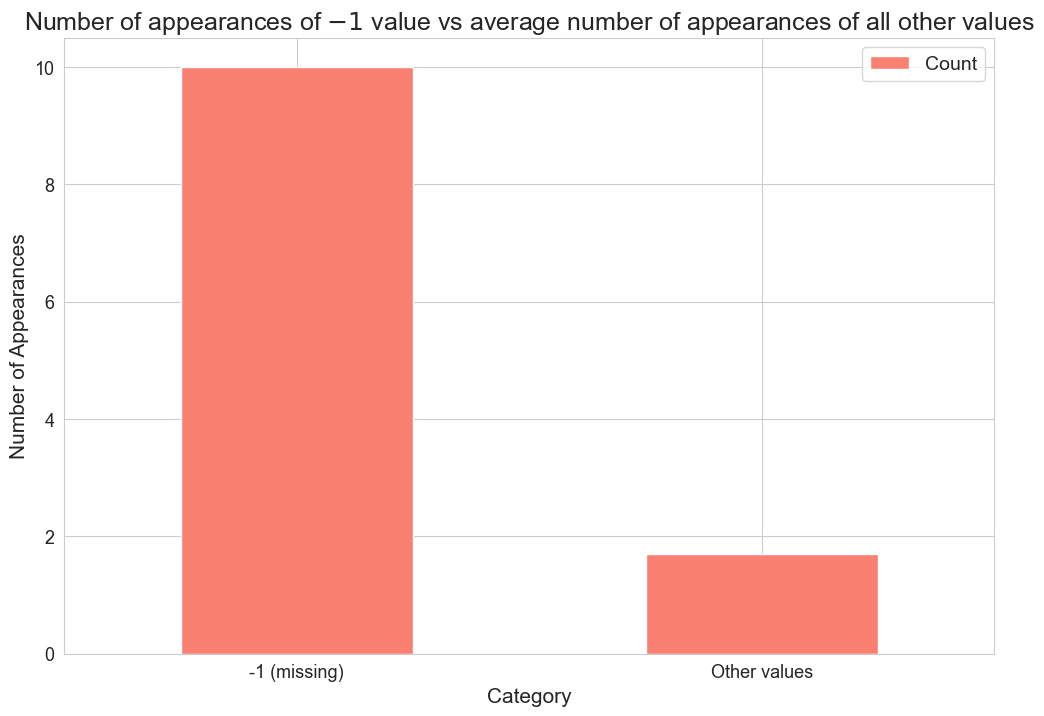

In [140]:
df["Pts_1"].value_counts()

fig, ax = plt.subplots(1, 1, figsize=(12,8))

# Getting columns and totals required for -1 frequency comparison
pts_1_total = df[["Pts_1"]].size
pts_2_total = df[["Pts_2"]].size

pts_1_minus = df[df["Pts_1"] == -1]["Pts_1"].size
pts_2_minus = df[df["Pts_2"] == -1]["Pts_2"].size

pts_1_not_minus = df[df["Pts_1"] != -1]["Pts_1"]
pts_2_not_minus = df[df["Pts_2"] != -1]["Pts_2"]

# Mean number of appearances of not -1 points
mean_1 = pts_1_not_minus.value_counts().mean()
mean_2 = pts_2_not_minus.value_counts().mean()

# Means across both pts_1 and pts_2
total_mean = mean_1 / 2 + mean_2 / 2
minus_1_mean = pts_1_minus / 2 + pts_2_minus / 2

plot_df = pd.DataFrame({
    'Category': ['-1 (missing)', 'Other values'],
    'Count': [minus_1_mean, total_mean]
})

plot_df.plot(kind="bar", x="Category", ax=ax, color="salmon", rot=0)
ax.set_title(r"Number of appearances of $-1$ value vs average number of appearances of all other values")
ax.set_ylabel("Number of Appearances")

In [86]:
# Extract all rows where either pts column entry is -1
rows = df[(df["Pts_1"] == -1) | (df["Pts_2"] == -1)]

# Extract all rows where neither point column has a -1 entry
rows_2 = df[(df["Pts_1"] != -1) & (df["Pts_2"] != -1)]

# Get the date of the last -1 row
date = rows.iloc[-1]["Date"]

# Check that dates of all -1 rows have dates earlier than this
check = (rows["Date"] <= date).all()

# Check that all dates of non -1 rows have dates later than this
check_2 = (rows_2["Date"] > date).all()

# Check both at once
check_both = (rows["Date"] <= date).all() & (rows_2["Date"] > date).all()
print(f"The only Djokovic matches where ATP points were not stored are all matches before {date}: {check_both}")

The only Djokovic matches where ATP points were not stored are all matches before 2005-06-25: True


Hence, we have identified that all of the matches with dates earlier than $25/06/2025$ did not have the pre-match ATP points stored, and that all matches after this date do have legitemate point entries.

Next, let us analyse the odds columns. Odds must be greater than $1$, otherwise it wouldn't make sense for any bookmaker to offer this as no rational person would accept odds less than $1$, since winning would mean you lose money.

In [87]:
print((df["Odd_1"] <= 1.0).any() & (df["Odd_2"] <= 1.0).any())

True


The above indicates that there do indeed exist rows with odd entries less than $1$. Let us work out how many of these exist.

In [88]:
# Extract number of "bad" odds rows
bad_rows = df[(df["Odd_1"] <= 1.0) | (df["Odd_2"] <= 1.0)]
bad_rows_num = bad_rows.shape[0]

# Extract total number of rows
total_size = df.shape[0]

# Calculate percentage of bad rows
pct = bad_rows_num / total_size * 100

print("Quick Odds Analysis")
print("-"*70)
print(f"The number of rows with odds less than or equal to 1 is {bad_rows_num}")
print(f"The total number of rows is {total_size}")
print(rf"The percentage of rows with odds less than or equal to 1 is {pct :.2f}%")

Quick Odds Analysis
----------------------------------------------------------------------
The number of rows with odds less than or equal to 1 is 18
The total number of rows is 1278
The percentage of rows with odds less than or equal to 1 is 1.41%


## 4. Win Distribution

Let us now analyse the distribution of our target variable: whether Djokovic was the winner of the match or not.

Quick Win Analysis
--------------------------------------------------
Total number of matches: 1278
Number of wins: 1072
Number of losses: 206
Win percentage: 83.88%


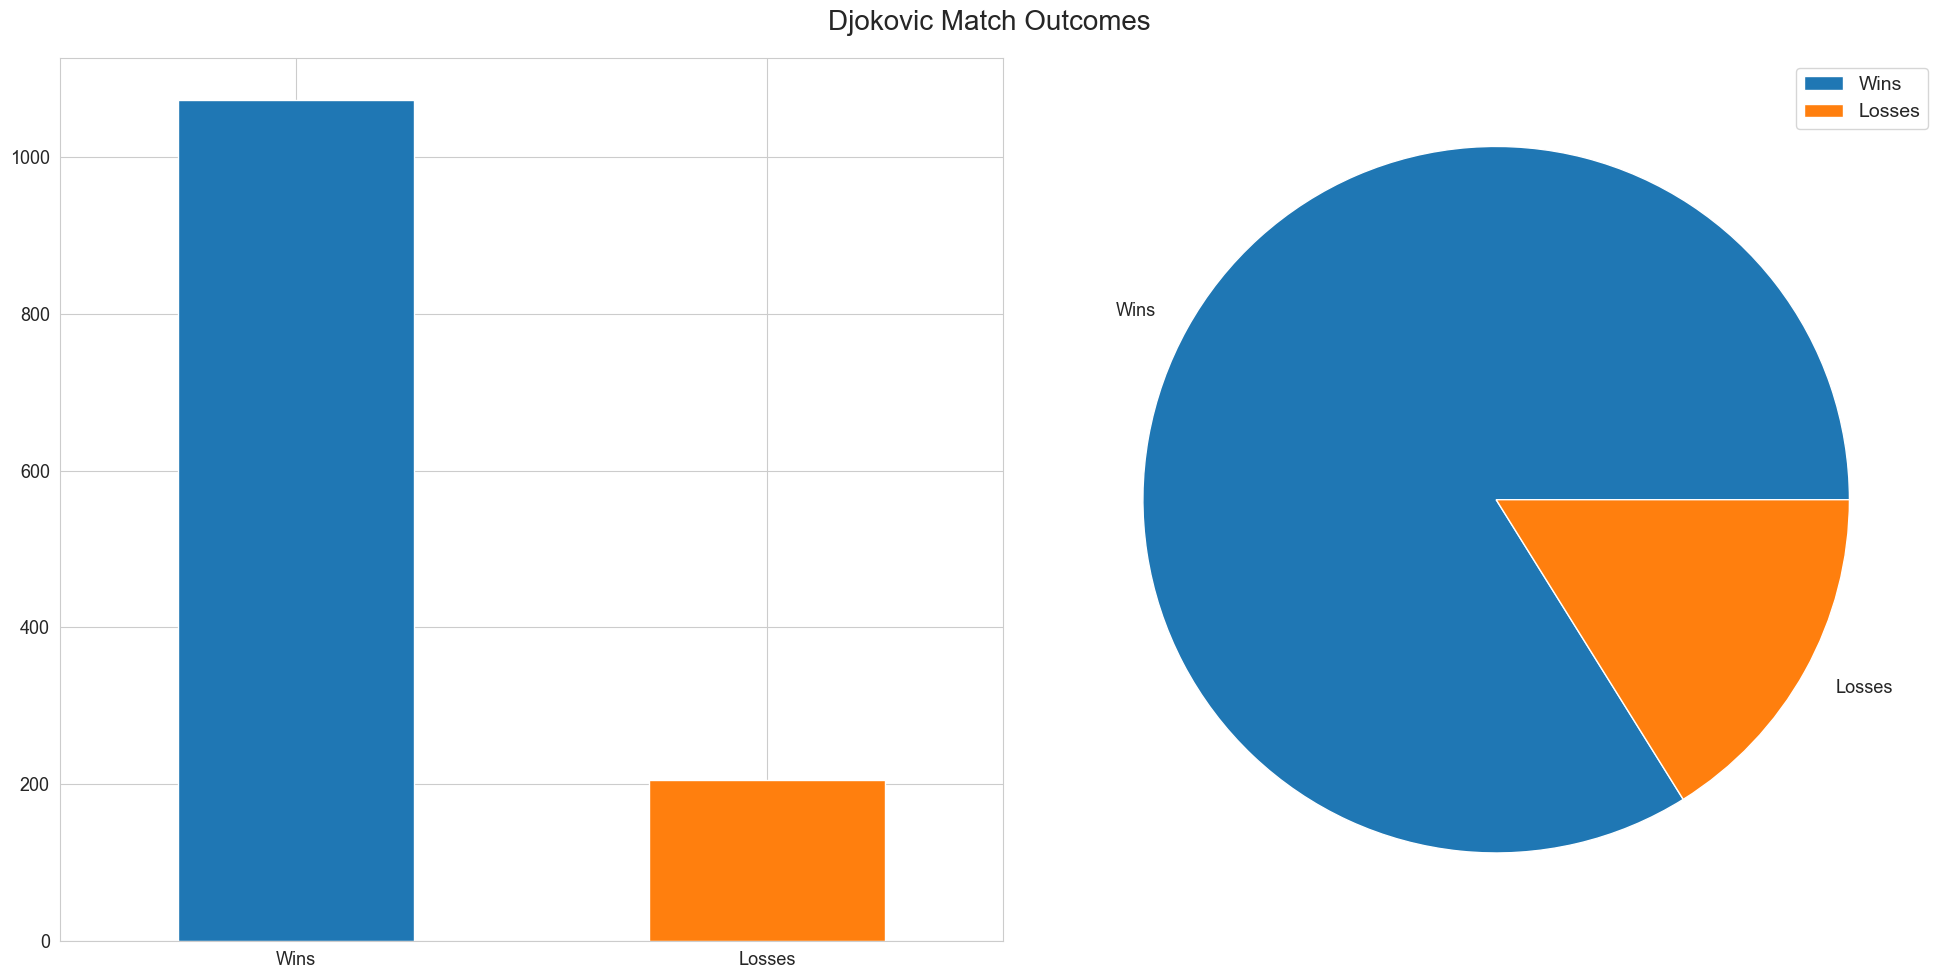

In [139]:
# Calculate number of wins, losses and win percentage
num_win = df[df["Djokovic Win"] == 1].shape[0]
num_loss = df[df["Djokovic Win"] == 0].shape[0]
win_pct = num_win / (num_loss + num_win) * 100

# Quick analysis print
print("Quick Win Analysis")
print("-"*50)
print(f"Total number of matches: {df.shape[0]}")
print(f"Number of wins: {num_win}")
print(f"Number of losses: {num_loss}")
print(f"Win percentage: {win_pct:.2f}%")

# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(20,10))

df_outcomes = pd.DataFrame({"Count": [num_win, num_loss]}, index=["Wins", "Losses"])

df_outcomes.plot(kind="bar", ax=ax[0], rot=0, y="Count", legend=False, color=["tab:blue", "tab:orange"])
df_outcomes.plot(kind="pie", ax=ax[1], y="Count")

ax[1].set_ylabel("")
fig.suptitle("Djokovic Match Outcomes", fontsize=20)
plt.tight_layout()
plt.show()